# Project Motivation

**Task** - the task is a to approximate a smooth non-linear function on a bounded 2D domain

Essentially this is a supervised regression task

As this project is for learning purposes rather pure practicality, we will be using a neural network even though there are more efficient methods of function interpolation.

### Why, can we use a neural network?
-- NEED TO ADD THAT WE CAN DO THIS USING UAT


Before we look at model architecture, training and so on, let's take a look at the data.

## Data Generation

For this project we will create synthetic data.
Here is the methodology :

We have some known smooth and non-linear function $f : [a,b]^2 \to \mathbb{R} , f(x,y)$   
where $a,b\in\mathbb{R}$

To generate the dataset, we take $n$ points $(x,y)\in[a,b]^2$
Then, we evaluate the function at these points and add some noise  
This gives us : $z_{i} = f(x_{i},y_{i}) + \epsilon_{i}\;\;1\leq i\leq n$ where $\epsilon_{i}\sim N(0,\sigma^2)\;\;i.d.d$  
This gives us the final dataset $\mathbf{D}=\{(x_{i} , y_{i} , z_{i}) \}_{i=1}^n$

This is implemented in the code below

So now we have our dataset $\mathbf{D}$, we can begin to think about the model and its implementation.

We need to : 

1) Choose a model
2) Choose a loss function
3) Choose weights that makes F a close approximation of the target function

#### (1) Choosing a model
We have already decided to use a neural network but we need to think about its structure.
For now, we will consider a simple Feed-Forward Network.

##### Feed-Forward Neural Network
<img src="fnn_diagram.png" alt="Feed-Forward Neural Network Diagram"/>

I have drawn this graph to show the general structure of an FNN.

An FNN simply consists of a set of "neurons" or "nodes" (taking inspiration from neurons in the brain).

These are modelled to be basic units of computation.
Typically, each neuron performs a weighted sum on its inputs and then adds some bias. To allow a network to capture more complex patterns, we then introduce non-linearity by applying a post activation function, giving a final output.
  
We then group a some of these neurons together, forming what we call a "layer".  
Thinking about a network in terms of its layers makes it easier when it comes to implementation.

We then take some these layers to form the network as shown above.  
The input layer just refers to the information we input into the network and does not actually perform any computation.  
The intermediate layers are called "hidden" because a user cannot directly interact with them. They perform most/all of the computation.  
Finally, we have the output layer which again doesn't perform any computation and is just the output of the network.  

How is everything connected?
Generally in an FNN, each neuron passes its output to every node in the next layer. This means that the network is "fully" connected.  
  
In different models, layers might not be sequentially arranged, the network might not be fully connected, and other modifications may be added. Additionally, we can make adjustments to model's architecture to improve the model's performance. 

How do we implement this/represent this mathematically?
  
*for convenience, i will explain everything in real numbers, but we can use different objects and so forth.*  
Representing a neuron:   
Suppose, we have $n$ inputs with the $i^{th}$ input, $x_i\in\mathbb{R}$ having weight $w_i\in\mathbb{R}$.  
We can then represent the weighted sum as $$\sum_{i=1}^{n}w_i x_i$$  
We can then add a bias term $b\in\mathbb{R}$, and then apply some activation function $\sigma:\mathbb{R}\to\mathbb{R}$
This gives us the output of a neuron $y\in\mathbb{R}$ as $$y=\sigma\big(\sum_{i=1}^n w_i x_i + b\big)$$


This is for one neuron, but what if we want to represent many neurons at once?  It would be quite messy to store and manage each neuron individually so we use linear algebra to help represent everything neatly.  
Notice that we can write the weighted sum for the $j^{th}$ node (with the $i^{th}$ input having a weight $w_ji$ for the $j^{th} node$) as $$\sum_{i=1}^n w_jix_i$$

This is actually the $i,j$ entry of some matrix multiplication $A\underline{x}$ where $A\in\mathbb{R}^{m \times n}$ and $\underline{x}\in\mathbb{R}^n$
# COMPLETE EXPLANATION

In [220]:
#Libraries needed

import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
from IPython.display import clear_output

In [221]:
rand = np.random.default_rng(42)


a = -10
b = 10
n = 1000

#Our target function f
def f(x,y):
    return x**2+y**2

def g(x,y):
    return np.sqrt(abs(1-x**2-y**2))

def h(x,y):
    return 1/(1+25*x**2)



xcoords = rand.uniform(low=a,high=b,size=(n,1))
ycoords = rand.uniform(low=a,high=b,size=(n,1))

zcoords = f(xcoords,ycoords)

dataset = np.concatenate((xcoords,ycoords,zcoords),axis=1)

#formatting coords for input
TestTrainSplit = 0.8
batches = 5
SplitIndex = int(TestTrainSplit*n)
TrainData  = dataset[:SplitIndex]
TestData = dataset[SplitIndex:]

noise = rand.normal(loc=0,scale=1,size=(SplitIndex,1))
TrainData[:,-1] = (TrainData[:,-1].reshape(SplitIndex,1) + noise).reshape(SplitIndex)


#scaling the dataset
mean = np.mean(TrainData,0)
SD = np.std(TrainData,0)

ScaledTrainData = (TrainData - mean)/SD

TrainDataBatches = np.split(TrainData,batches)

#Simple scatter plot for visualisation
fig = px.scatter_3d(TrainData,x=0,y=1,z=2)
fig.show()

In [222]:
def ReLu(x):
    return np.maximum(0,x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def swish(x):
    return x * sigmoid(x)
def MSE(labels,predictions):
    loss = np.sum((predictions - labels)**2)
    loss = loss/predictions.shape[0]
    return loss

def RMSE(labels,predictions):
    loss = MSE(labels,predictions)
    return np.sqrt(loss)


def MinMax(x,min,max):
    return (x-min)/(max-min)

def InvMinMax(x,min,max):
    return  x * (max-min) + min

def normalise(x,mean,var,epsilon=1e-5):
    return (x-mean)/np.sqrt(var+epsilon)

def InvNormalise(x,mean,var,epsilon=1e-5):
    return x * np.sqrt(var + epsilon) + mean

In [223]:
#LayerWidths -> an arr storing the number of neurons in the (k+1)th layer (left to right)
#PostActFuncs -> an arr storing the post-act func of each layer
class network:
    def __init__(self, LayerWidths,PostActivationFuncs):
        self.LayerNum = len(LayerWidths)-1
        self.LayerWidths = LayerWidths
        self.PostActivationFuncs = PostActivationFuncs
        self.layers = []
        self.LayerOutputs = []
        for i in range(1,self.LayerNum+1):
            layeri= layer(LayerWidths[i-1],LayerWidths[i],PostActivationFuncs[i])
            self.layers.append(layeri)


    def ForwardPass(self,input):
        self.LayerOutputs.clear()
        for i in range(self.LayerNum):
           input , LayerComputations = self.layers[i].compute(input)
           self.LayerOutputs.append(LayerComputations)

        return input

class layer:
    def __init__(self,InputWidth,width,PostActFunc):
        sigma = np.sqrt(2/(InputWidth+width))
        self.width = width
        self.PostActFunc = PostActFunc
        self.InputWidth = InputWidth
        self.weights = np.array(rand.normal(0,sigma, size=(width,InputWidth)))
        self.bias = np.array(rand.normal(0,sigma, size=(width,1)))
        #stochatistcally initialise a matrix


    def compute(self,input):
        computations = {}
        LinearComputation = self.weights@input + self.bias
        computations["Linear"] = LinearComputation


        PostActComputation = self.PostActFunc(LinearComputation)
        computations["LayerOutput"] = PostActComputation
        return PostActComputation , computations

In [224]:
#formed the netowrk
fnn = network([2,128,128,128,1],[lambda x : x,np.tanh,np.tanh,np.tanh,lambda x : x])

In [225]:
def GradDesc(CurrVal,Gradient,LearningRate=0.001):
    return CurrVal - LearningRate*Gradient

In [226]:
BatchLossVals = [[] for i in range(batches)]
TotalLossVals = []
epochs = int(2000)
LearningRate = 1e-1
RegParam = 0.0
loss = 0
InputShape = (2,1)


for epoch in range(epochs):
    indexes = np.arange(0,len(TrainDataBatches)-1)
    np.random.shuffle(indexes)

    for index in indexes:
        CurrentBatch = TrainDataBatches[index]
        N = CurrentBatch.shape[0]

        W4 = fnn.layers[3].weights
        b4 = fnn.layers[3].bias

        W3 = fnn.layers[2].weights
        b3 = fnn.layers[2].bias

        W2 = fnn.layers[1].weights
        b2 = fnn.layers[1].bias

        W1 = fnn.layers[0].weights
        b1 = fnn.layers[0].bias

        dW4 = np.zeros((W4.shape))
        db4 = np.zeros((b4.shape))

        dW3 = np.zeros((W3.shape))
        db3 = np.zeros((b3.shape))

        dW2 = np.zeros((W2.shape))
        db2 = np.zeros((b2.shape))

        dW1 = np.zeros((W1.shape))
        db1 = np.zeros((b1.shape))

        predictions = np.zeros((N,1))
        labels = np.zeros((N,1))

        for i in range(N):
            x = CurrentBatch[i,:-1].reshape(InputShape)
            label = CurrentBatch[i,-1]
            prediction = fnn.ForwardPass(x)

            predictions[i] = prediction
            labels[i] = label

            #layer 4
            a3_i = fnn.LayerOutputs[2]["LayerOutput"]

            dLdy_i = 2/N * (prediction - label)
            db4 += dLdy_i
            dW4 += dLdy_i * a3_i.T

            #layer 3
            a2_i = fnn.LayerOutputs[1]["LayerOutput"]

            delta3 = (W4.T * dLdy_i) * (1 - a3_i ** 2)

            dW3 += delta3 @ a2_i.T
            db3 += delta3

            #Layer 2
            a1_i = fnn.LayerOutputs[0]["LayerOutput"]

            delta2 = (W3.T @ delta3) * (1-a2_i**2)

            dW2 += delta2 @ a1_i.T
            db2 += delta2

            #Layer 1
            delta1 = (W2.T @ delta2) * (1-a1_i**2)

            dW1 += delta1 @ x.T
            db1 += delta1



        fnn.layers[3].bias = GradDesc(b4,1/N * db4,LearningRate)
        fnn.layers[3].weights = GradDesc(W4,1/N * dW4,LearningRate)

        fnn.layers[2].bias = GradDesc(b3,1/N * db3,LearningRate)
        fnn.layers[2].weights = GradDesc(W3,1/N * dW3,LearningRate)

        fnn.layers[1].bias = GradDesc(b2,1/N * db2,LearningRate)
        fnn.layers[1].weights = GradDesc(W2,1/N * dW2,LearningRate)

        fnn.layers[0].bias = GradDesc(b1,1/N * db1,LearningRate)
        fnn.layers[0].weights = GradDesc(W1,1/N * dW1,LearningRate)


        loss =  MSE(labels,predictions)
        BatchLossVals[index].append(loss)
        TotalLossVals.append(loss)

    print(f"epoch: {epoch}, loss: {loss}")













epoch: 0, loss: 5951.770792347223
epoch: 1, loss: 5659.336722586932
epoch: 2, loss: 4603.808425296316
epoch: 3, loss: 4497.473680958821
epoch: 4, loss: 3472.9664574267854
epoch: 5, loss: 3056.5460623068043
epoch: 6, loss: 3153.7456562551934
epoch: 7, loss: 1988.6698105773662
epoch: 8, loss: 2123.49122357019
epoch: 9, loss: 1904.086217695778
epoch: 10, loss: 1903.7277243141557
epoch: 11, loss: 1818.8356328910588
epoch: 12, loss: 1527.4305589717264
epoch: 13, loss: 1518.8421263411394
epoch: 14, loss: 1790.8759660043136
epoch: 15, loss: 1771.3837194022628
epoch: 16, loss: 1474.0866808740325
epoch: 17, loss: 1757.5277121763697
epoch: 18, loss: 1634.5080344201083
epoch: 19, loss: 1502.8857057990888
epoch: 20, loss: 1406.065148835943
epoch: 21, loss: 1319.444000868843
epoch: 22, loss: 1224.910869863971
epoch: 23, loss: 1436.10163703672
epoch: 24, loss: 1081.3456994414137
epoch: 25, loss: 1054.0303640576662
epoch: 26, loss: 866.5975167262856
epoch: 27, loss: 1163.0860758359863
epoch: 28, loss

In [227]:
for layer in fnn.layers:
    print(f"weight : {layer.weights}")

weight : [[-0.04879083 -0.39312731]
 [ 0.01432894 -0.40073895]
 [ 0.03160647  0.34152807]
 [-0.1832564  -0.10938011]
 [ 0.08381075  0.36211997]
 [ 0.08937446 -0.41974979]
 [ 0.14544573  0.11474915]
 [ 0.07082196 -0.1660076 ]
 [-0.18027123  0.15947937]
 [ 0.45692292 -0.00599499]
 [ 0.16234629  0.13274366]
 [-0.15809889 -0.06406411]
 [-0.09308038 -0.16618941]
 [-0.04195546  0.45488965]
 [ 0.17825718  0.09317117]
 [-0.29213164  0.0974389 ]
 [-0.00967215  0.351038  ]
 [ 0.00364966 -0.39608022]
 [-0.49311154  0.13795528]
 [-0.13557164 -0.19861092]
 [-0.17604378 -0.08400218]
 [ 0.24740415  0.15344467]
 [ 0.12850628  0.13392875]
 [ 0.05667773 -0.43709641]
 [-0.16681709 -0.07282357]
 [ 0.04525827  0.15657604]
 [ 0.1222842  -0.11653324]
 [-0.11626757 -0.13920325]
 [ 0.12945094  0.14336398]
 [ 0.51676697 -0.04036183]
 [ 0.05902086 -0.14620625]
 [-0.03280241  0.37690758]
 [-0.17201257 -0.13415035]
 [-0.17901584 -0.14236841]
 [-0.00624228  0.19791212]
 [ 0.42315064  0.0518937 ]
 [ 0.43312406 -0.01

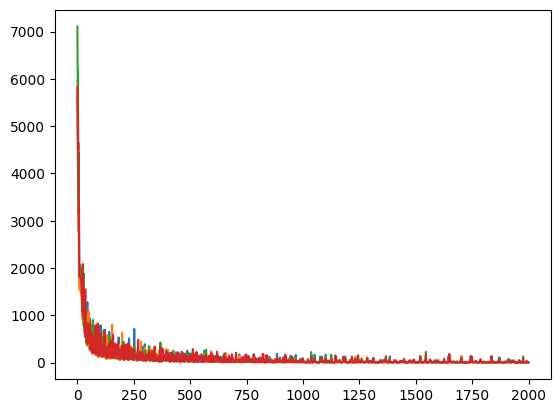

In [228]:
for j in range(len(BatchLossVals)):
    plt.plot([i for i in range(len(BatchLossVals[j]))],BatchLossVals[j])
plt.show()

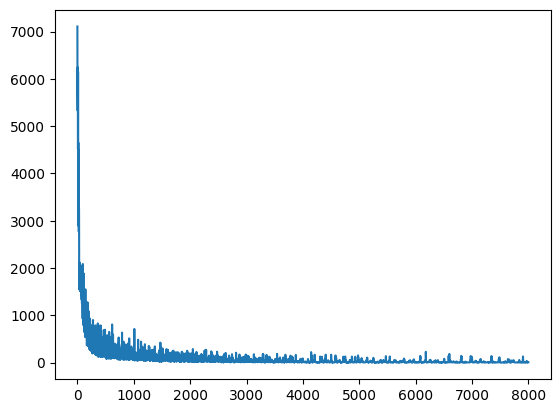

In [229]:
plt.plot(np.arange(0,len(TotalLossVals)),TotalLossVals)
plt.show()

In [230]:
TestPredictions = np.zeros((TestData.shape[0],1))

for i in range(TestData.shape[0]):
    x = TestData[i,:-1].reshape(InputShape)
    TestPrediction = fnn.ForwardPass(x)
    TestPredictions[i] = TestPrediction
    print(f"prediction : {TestPrediction[0][0]}, actual value : {TestData[i,-1]}")


TestLabels = TestData[:,-1].reshape(TestData.shape[0],1)
TestLoss = RMSE(TestLabels,TestPredictions)

print(f"RMSE on test is {TestLoss}")

prediction : 26.66940421816344, actual value : 27.63779952865368
prediction : 18.758426448931402, actual value : 19.478667311889932
prediction : 110.53627712264289, actual value : 114.11277399135493
prediction : 17.528422128067383, actual value : 18.504834044466683
prediction : 67.73479958100164, actual value : 68.15759364897042
prediction : 63.41680969648885, actual value : 64.10992582788951
prediction : 85.95430467352558, actual value : 87.48069517818993
prediction : 43.6996434790447, actual value : 43.916710954348304
prediction : 2.6367554988435726, actual value : 3.331116279321026
prediction : 159.72310555591727, actual value : 165.0598131709455
prediction : 120.05612497631095, actual value : 129.23520944906787
prediction : 92.396365508044, actual value : 94.8721995110478
prediction : 117.76096810559385, actual value : 120.85435212258128
prediction : 29.600400355749404, actual value : 30.52003344128398
prediction : 97.63456504574988, actual value : 99.17246783799351
prediction : 64

In [231]:
## Linear regression

import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import mean_squared_error

X_train = TrainData[:,:-1]
y_train = TrainData[:,-1]
X_test = TestData[:,:-1]
y_test = TestData[:,-1]
# baselines
poly = LinearRegression().fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
gp = GaussianProcessRegressor(kernel=RBF(length_scale=0.5)).fit(X_train, y_train)

print("Poly MSE:", mean_squared_error(y_test, poly.predict(PolynomialFeatures(2).fit_transform(X_test))))
print("GP MSE:  ", mean_squared_error(y_test, gp.predict(X_test)))
# then compare your NN's MSE to these

Poly MSE: 0.008758936142661074
GP MSE:   192.72874228733298


c:\Users\arhaa\Projects\ml\Intro-Neural-Net-Proj\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning:

lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html

